In [32]:
# import libraries
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv(r"C:\Users\hamen\OneDrive\Desktop\project2\dataset\zomato_clean_dataset.csv")
df.head()

,name,online_order,book_table,rate,votes,cost_of_two_customers,listing_type
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [24]:
# connect to my sqlite database
conn = sqlite3.connect(r"C:\Users\hamen\OneDrive\Desktop\project2\database\zomato_database.db")

In [25]:
# convert csv to sqlite table
df.to_sql("zomato_custo",conn,if_exists="replace",index=False)

148

In [28]:
q ="""select*from zomato_custo;"""
df = pd.read_sql(q,conn)
df

,name,online_order,book_table,rate,votes,cost_of_two_customers,listing_type
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining


In [35]:
# type of restrunt
q = """  select listing_type,count(*) total_cust from zomato_custo group by listing_type order by total_cust desc; """
df1 = pd.read_sql(q,conn)
df1

,listing_type,total_cust
0,Dining,110
1,Cafes,23
2,other,8
3,Buffet,7


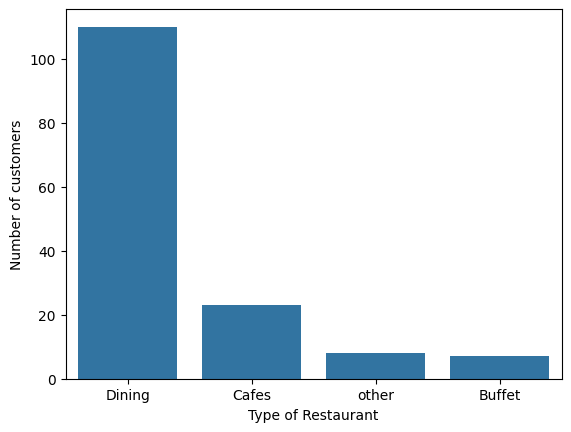

In [44]:
# make chart
sns.barplot(data=df1,x="listing_type",y="total_cust")
plt.xlabel("Type of Restaurant")
plt.ylabel("Number of customers")
plt.show()

In [45]:
# conclusion : Major of the customers go Dinning restaurant

In [57]:
# How many vote Different Restaurant get by different customers
q = """select listing_type,sum(votes) Total from zomato_custo group by listing_type order by Total asc"""
df2 = pd.read_sql(q,conn)
df2

,listing_type,Total
0,Buffet,3028
1,Cafes,6434
2,other,9367
3,Dining,20363


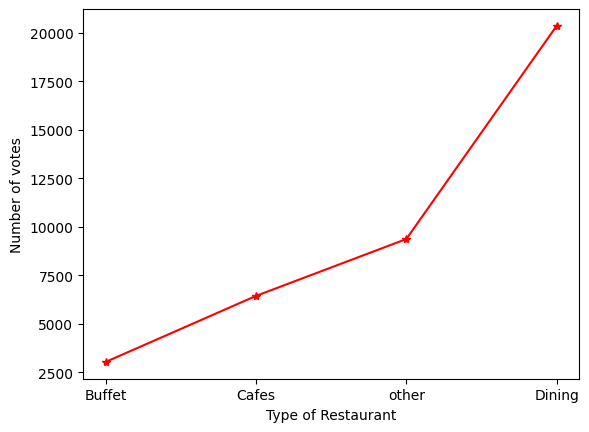

In [58]:
plt.plot(df2["listing_type"],df2["Total"],c="Red",marker="*")
plt.xlabel("Type of Restaurant")
plt.ylabel("Number of votes")
plt.show()

In [59]:
# Conclusion - Dinning resturants has recieved maximum votes

In [83]:
# which Restaurant got most rating
q = """ select listing_type, count(rate) as total_rating from zomato_custo group by listing_type """
df3 = pd.read_sql(q,conn)
df3

,listing_type,total_rating
0,Buffet,7
1,Cafes,23
2,Dining,110
3,other,8


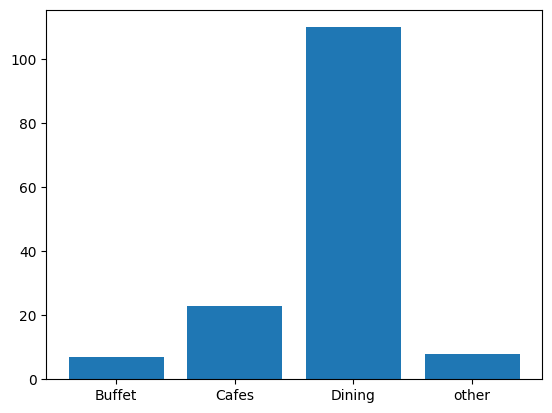

In [76]:
plt.bar(df3["listing_type"],df3["total_rating"])
plt.show()

In [78]:
# what are the rating that the majority of restaurant have received
q = """ select rate from zomato_custo"""
df4 = pd.read_sql(q,conn)
df4

,rate
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8
...,...
143,3.3
144,3.3
145,4.0
146,3.0


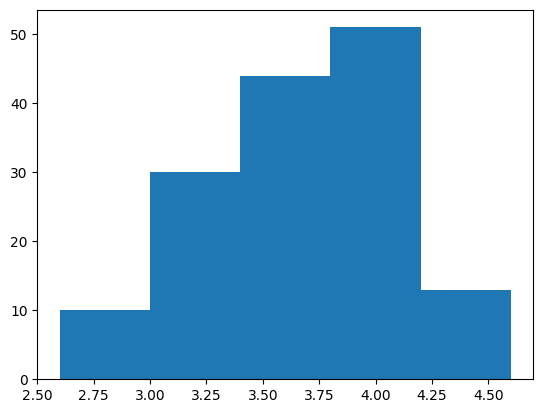

In [81]:
plt.hist(df4["rate"],bins=5)
plt.show()

In [82]:
# Conclusion: the majority resturants received rating from 3.75 to 4.15

In [90]:
# average purchase cost customer who have order online

q = """ select online_order, avg(cost_of_two_customers)as avg_purchase_cost from zomato_custo group by online_order"""
df5 = pd.read_sql(q,conn)
df5

,online_order,avg_purchase_cost
0,No,358.888889
1,Yes,510.344828


In [94]:
# Zomato has observed that most couples order most of their food online. what is their average spending on each order?
q = """select cost_of_two_customers from zomato_custo order by cost_of_two_customers desc"""
df6 = pd.read_sql(q,conn)
df6

,cost_of_two_customers
0,950
1,900
2,900
3,850
4,850
...,...
143,100
144,100
145,100
146,100


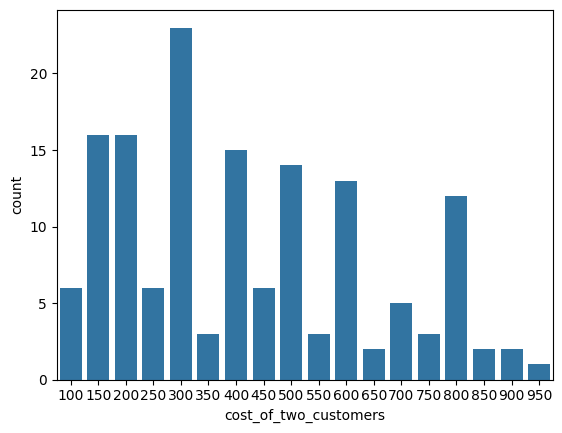

In [95]:
sns.countplot(data=df6,x="cost_of_two_customers")
plt.show()

In [96]:
# conclusion: the majority of couples preferr resturant with an appreximate cost of 300 rupees

In [101]:
# which mode (online / offline) has received the maximum rating
q = """select online_order,rate from zomato_custo"""
df7 = pd.read_sql(q,conn)
df7

,online_order,rate
0,Yes,4.1
1,Yes,4.1
2,Yes,3.8
3,No,3.7
4,No,3.8
...,...,...
143,No,3.3
144,No,3.3
145,Yes,4.0
146,No,3.0


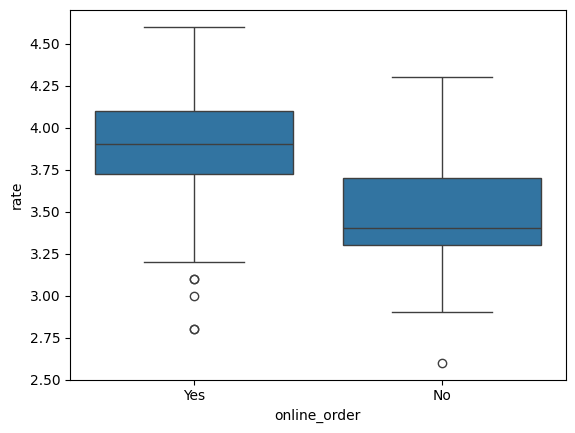

In [102]:
sns.boxplot(x="online_order",y="rate",data=df7)
plt.show()

In [103]:
# conclusion : offline order receive lower rating compare to online order

In [113]:
# which type  of restaurant received how much offline and online orders
q  = """ select listing_type,online_order,count(*) as total_customers from zomato_custo group by listing_type,online_order; """
df9 = pd.read_sql(q,conn)
df9

,listing_type,online_order,total_customers
0,Buffet,No,3
1,Buffet,Yes,4
2,Cafes,No,8
3,Cafes,Yes,15
4,Dining,No,77
5,Dining,Yes,33
6,other,No,2
7,other,Yes,6


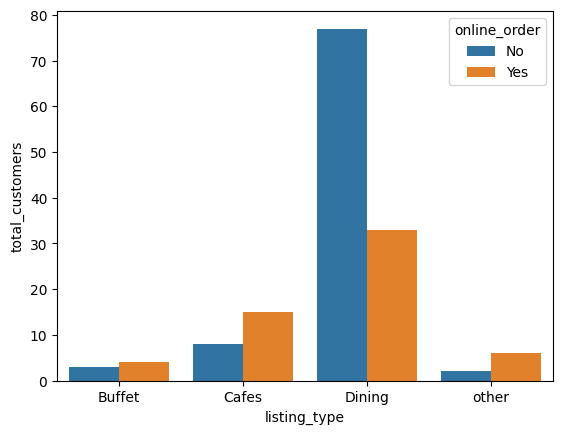

In [116]:
sns.barplot(x="listing_type",y="total_customers",hue = "online_order", data = df9)
plt.show()

In [117]:
# conclusion: in Dinning online order is less compare to buffet,other,cafe and offline order is high in dinning compare to other